In [1]:
import chromadb
#import openai
from chromadb.config import Settings
from chromadb import PersistentClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Compare text description of each artefact**

In [2]:
client = PersistentClient(path="./chroma_db")

# create a collection
collection = client.create_collection(
    name="pdf_upgrd_description",
    configuration={
        "hnsw": {
            "space": "cosine",       # better for text
            "ef_construction": 200,
            "ef_search": 150
        }
    }
)

#client.delete_collection("pdf_upgrd_description")

In [13]:
df_txt = pd.read_csv("../data/raw/pdf_web_artefacts.csv", sep = ';', encoding="utf-8").copy()
# need to keep only filled columns for text comparison
df_txt = df_txt[df_txt["pdf_upgrd_description"].notna() & (df_txt["pdf_upgrd_description"] != "")]

In [14]:
# add documents to collection (web) 
collection.add(
    ids=[f"b_{i}" for i in range(len(df_txt))] + [f"c_{i}" for i in range(len(df_txt))],
    documents=df_txt["wb_txt_shrt"].tolist() + df_txt["wb_txt_lg"].tolist(),
    metadatas=[{"source": "wb_txt_shrt", "artifact_id": str(v)} for v in df_txt["artifact_id"]] +
              [{"source": "wb_txt_lg", "artifact_id": str(v)} for v in df_txt["artifact_id"]],
)

# results for each
res_B = collection.query(
    query_texts=df_txt["pdf_upgrd_description"].tolist(),
    n_results=1,
    where={"source": "wb_txt_shrt"},
    include=["distances", "metadatas"]
)

res_C = collection.query(
    query_texts=df_txt["pdf_upgrd_description"].tolist(),
    n_results=1,
    where={"source": "wb_txt_lg"},
    include=["distances", "metadatas"]
)

# viz df
df_txt["wb_txt_shrt_dist"] = [d[0] for d in res_B["distances"]]
df_txt["wb_txt_lgidst"] = [d[0] for d in res_C["distances"]]


In [26]:
#df_txt.to_csv("../data/raw/first_text_scoring.csv",sep = ';', encoding="utf-8-sig")

**Compare images of each artefact**

*Note: use of chroma db for testing, but dataset < 1k so not necessary, DINO2 en Hugging face could be a good option as well*

In [16]:
from chromadb.utils.data_loaders import ImageLoader
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction

In [18]:
client = chromadb.Client()

#client.delete_collection("collection_pdf")

In [19]:
# get the pdf images
df_pdf = pd.read_csv("../data/clean/pdf_images.csv", sep = ';', encoding="utf-8-sig")
pdf_img = df_pdf[['artifact_id','image_path','image_name']]
ids_pdf = df_pdf['image_name'].astype(str).tolist()
pdf_paths = df_pdf['image_path'].astype(str).tolist()
pdf_artifacts = df_pdf['artifact_id'].astype(str).tolist()


In [20]:
# get the web images
df_web = pd.read_csv("../data/clean/web_photos.csv", sep = ';', encoding="utf-8-sig")
web_img = df_web[['artifact_id','image_path','image_name']]
ids_web = df_web['image_name'].astype(str).tolist()
web_paths = df_web['image_path'].astype(str).tolist()
web_artifacts = df_web['artifact_id'].astype(str).tolist()

In [21]:
# create collections of images (fucntional set-up)
client = chromadb.Client()

collection_pdf = client.create_collection(
    name="collection_pdf",
    embedding_function=OpenCLIPEmbeddingFunction(),
    data_loader=ImageLoader(),
    configuration={
        "hnsw": {
            "space": "cosine",
            "ef_construction": 200,
            "ef_search": 150
        }
    }
)


collection_web = client.create_collection(
    name="collection_web",
    embedding_function=OpenCLIPEmbeddingFunction(),
    data_loader=ImageLoader(),
    configuration={
        "hnsw": {
            "space": "cosine",
            "ef_construction": 200,
            "ef_search": 150
        }
    }
)

In [115]:
# Add images (note: metadata enables to store artifact_id)
# PDF with extracted ids
metadatas_pdf = [
    {"common_id": artifact, "source": "pdf"}
    for artifact in pdf_artifacts
]

collection_pdf.add(
    ids=ids_pdf,
    uris=pdf_paths,
    metadatas= metadatas_pdf
)

# WEB with extracted ids
metadatas_web = [
    {"common_id": artifact, "source": "web"}
    for artifact in web_artifacts
]

collection_web.add(
    ids=ids_web,
    uris=web_paths,
    metadatas=metadatas_web
)

In [22]:
# find matching

pdf_set = set(pdf_artifacts)
web_set = set(web_artifacts)
common_ids = pdf_set & web_set

results = {}

# loop on artifact and search web images with the same artifact id and similar
for artifact_id in common_ids:
    pdf_images = collection_pdf.get(
        where={"common_id": artifact_id},
        include=["embeddings"]
    )
    
    if len(pdf_images["embeddings"]) > 0:
        query_results = collection_web.query(
            query_embeddings=pdf_images["embeddings"],
            where={"common_id": artifact_id},
            n_results=10,
            include=["distances", "metadatas"]
        )
        results[artifact_id] = query_results

  
# to see results
#for key, value in results.items():
    #print(f"Artifact {key}: distances = {value['distances']}")

In [117]:
# convert resultats in dataframe
rows = []

for artifact_id in common_ids:
    pdf_images = collection_pdf.get(
        where={"common_id": artifact_id},
        include=["embeddings", "metadatas"]
    )
    
    if len(pdf_images["embeddings"]) > 0:
        query_results = collection_web.query(
            query_embeddings=pdf_images["embeddings"],
            where={"common_id": artifact_id},
            n_results=10,
            include=["distances", "metadatas"]
        )
        
        # for each pdf image
        for i, pdf_id in enumerate(pdf_images["ids"]):
            # for each compared web image
            for j, web_id in enumerate(query_results["ids"][i]):
                rows.append({
                    "artifact_id": artifact_id,
                    "image_pdf": pdf_id,
                    "image_web": web_id,
                    "score": query_results["distances"][i][j]
                })

df_results = pd.DataFrame(rows)
# .loc to get the full row, idx to get consistent and corresponding image_pdf, and image_web and min score
best = df_results.loc[df_results.groupby("artifact_id")["score"].idxmin()]

best.to_csv("../data/raw/best_image_score.csv", sep = ";" , encoding = "utf-8")

**Create the final scoring**

In [31]:
#score_txt = pd.read_csv("../data/raw/first_text_scoring.csv", sep = ";", encoding="utf-8-sig")
#score_img = pd.read_csv("../raw/raw/best_image_score.csv", sep = ",", encoding="utf-8-sig")

score_txt = pd.read_csv("../data/raw/first_text_scoring.csv", sep = ";", encoding="utf-8")
score_img = pd.read_csv("../data/raw/best_image_score.csv", sep = ";", encoding="utf-8")

# keep only best text score
score_txt['score_txt'] = score_txt[['wb_txt_shrt_dist','wb_txt_shrt_dist']].min(axis = 1)
score_img.rename(columns = {'score':'score_img'}, inplace=True)

artifact_score = score_txt.merge(score_img, on = 'artifact_id', how = 'outer')
artifact_score[['score_txt','score_img']] = artifact_score[['score_txt','score_img']].replace(np.nan,0)
artifact_score['final_score'] = (artifact_score['score_img'] + artifact_score['score_txt'])/2
final_score = artifact_score[['artifact_id', 'score_txt', 'score_img', 'final_score']]

def conditions(row):
    if (row['score_txt'] == 0) & (row['score_img'] != 0):
        val = 'score_img only'
    elif (row['score_txt'] != 0) & (row['score_img'] == 0):
        val = 'score_txt only'
    else:
        val = 'combined score'  
    return val

#Apply the function to each data point in the data frame
final_score['score_type']= final_score.apply(conditions, axis=1)

final_score['index'] = final_score.index+1
#final_score.to_csv("../data/raw/match_scoring.csv.csv", encoding = 'utf-8')

In [121]:
final_score.describe()

,score_txt,score_img,final_score
count,246.000000,246.000000,246.000000
mean,0.320816,0.081807,0.201311
std,0.119451,0.168934,0.079672
min,0.000000,0.000000,0.000343
25%,0.282907,0.000000,0.160836
50%,0.338189,0.032827,0.196418
75%,0.401839,0.070609,0.229478
max,0.518909,0.962525,0.626723


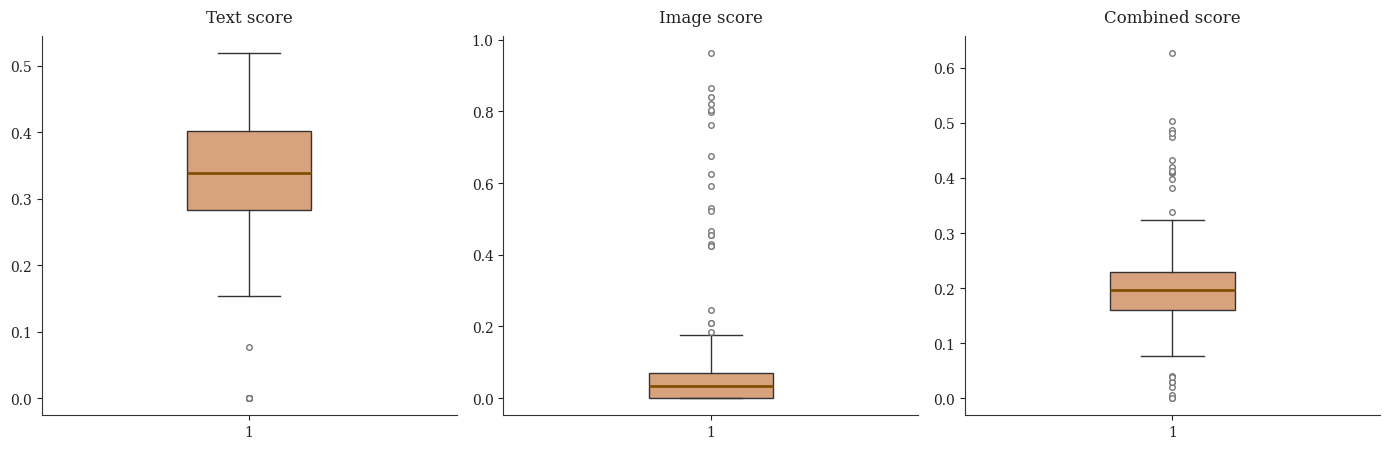

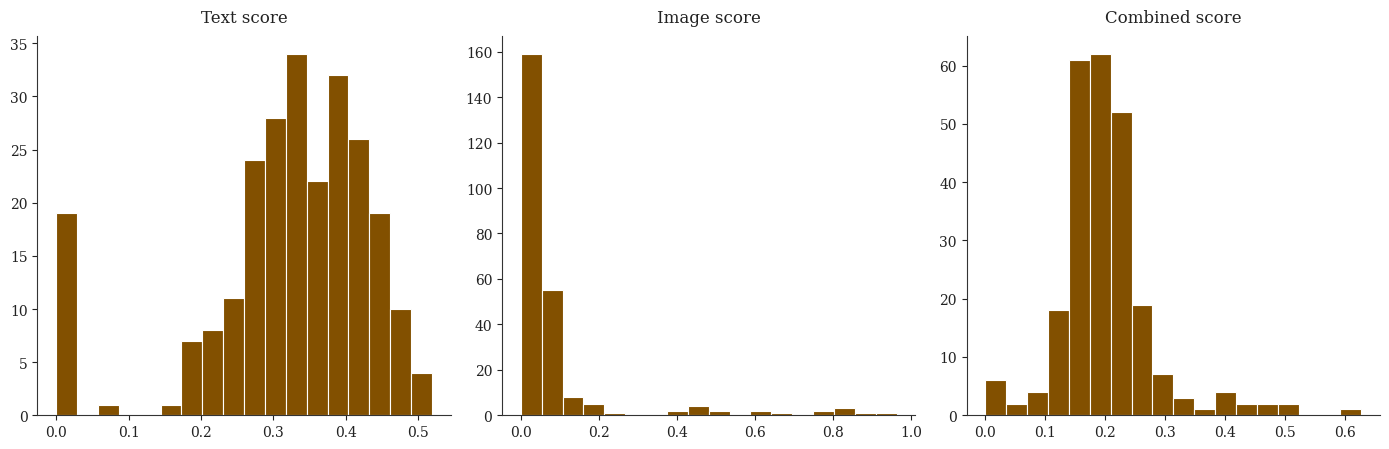

In [33]:
columns = final_score[['score_txt', 'score_img', 'final_score']]

# style params
plt.rcParams.update({
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "text.color": "#222222",
    "font.family": "serif",
})

# colors to match with presentation graphic chart
accent = "#825000"       # brown
accent_light = "#D9A27E"
dark = "#333333"
mid = "#777777"

titles = ["Text score", "Image score", "Combined score"]

series = [
    final_score['score_txt'].dropna(),
    final_score['score_img'].dropna(),
    final_score['final_score'].dropna()
]

# boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

for ax, values, title in zip(axes, series, titles):
    ax.boxplot(
        values,
        patch_artist=True,
        widths=0.3,
        boxprops=dict(facecolor=accent_light, edgecolor=dark),
        medianprops=dict(color=accent, linewidth=2),
        whiskerprops=dict(color=dark),
        capprops=dict(color=dark),
        flierprops=dict(
            marker='o',
            markerfacecolor='white',
            markeredgecolor=mid,
            markersize=4,
            linestyle='none'
        )
    )
    ax.set_title(title, pad=10)

    # remove grid
    ax.grid(False)

    # clean look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
#plt.savefig("../figures/bplot.png", transparent=True, dpi=300)
plt.show()

# histograms
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

for ax, values, title in zip(axes, series, titles):
    ax.hist(
        values,
        bins=18,
        color=accent,
        edgecolor="white",
        linewidth=0.8
    )
    ax.set_title(title, pad=10)

    # same grid remove
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
#plt.savefig("../figures/hist.png", transparent=True, dpi=300)
plt.show()